# Image Harvest — minimal reproduction of the paper's local RGB processing pipeline (Fig. 1A style)

**Paper:** Knecht, A.C., Campbell, M.T., Caprez, A., Swanson, D., Walia, H. (2016).
*Image Harvest: an open-source platform for high-throughput plant image processing and analysis.*
**Journal of Experimental Botany** 67(11):3587–3599. doi:[10.1093/jxb/erw176](https://doi.org/10.1093/jxb/erw176) (open access, CC-BY; PMC4892737).

**Author code:** Image Harvest (`ih`) repository, `git.unl.edu/aknecht2/ih`,
pinned commit `86162d6222ddaf44cd7993651cf238212d382cf7` (GPL).

**Scope (single example):** run the paper's local RGB side-view pipeline —
`crop` → `colorFilter` → `contourChop` → `contourCut` — exactly as in the author
example script `examples/scripts/camera1/camera1.py`, on the author-shipped example
image `examples/scripts/camera1/IMG_6050.JPG`, then extract the digital traits
(`extractPixels`, `extractConvexHull`). We compare each step against the author's
saved reference outputs shipped in the same directory (`IMG_6050_crop.png`,
`IMG_6050_thresh.png`, `IMG_6050_chop.png`, `IMG_6050_final.png`).

**Execution status:** executed / validated on a fresh Google Colab **CPU** runtime (see final cell for the validation record).
This is a one-image demonstration, **not** a reproduction of the paper's dataset-level benchmarks or GWAS.

**Japanese summary (要点):**
本ノートブックは、論文 Fig. 1A 相当の前処理パイプライン（crop → colorFilter → contourChop → contourCut）を
著者公開リポジトリ同梱のサンプル画像 1 枚に実行し、デジタル形質（投影画素数・凸包面積）を抽出する最小再現例です。
著者の保存済み参照出力との比較結果も表示します。GPU は不要で CPU ランタイムで動作します。

> **AI-assisted port notice:** The authors released Image Harvest for Python 2 / OpenCV 2.4.
> This notebook contains an **AI-assisted Python 3 port of a subset of `ih/imgproc.py` + `ih/conf.py`**
> (exact numerical operations preserved; see the port cell for the full mapping). The authors did not
> provide this Colab implementation; untested behavior beyond the executed example is not guaranteed.
> **日本語:** 本ノートブックの処理関数は著者コード（Python 2 版）を Python 3 向けに移植したものです。数値操作は原文のまま保持しています。

## Runtime selection / 実行環境の選択

**Use a CPU runtime** (`ランタイム` → `ランタイムのタイプを変更` → `CPU`). This pipeline is plain
OpenCV/numpy on one image — seconds of compute, no GPU, no CUDA, no model weights.
`ランタイム` → `すべてのセルを実行` runs the whole notebook end to end
(expected total: well under 2 minutes, ~15 MB of downloads).

In [ ]:
import sys, importlib.util
print("Python:", sys.version)
spec = importlib.util.find_spec("cv2")
if spec is None:
    # Colab usually ships OpenCV preinstalled; install only if missing.
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
import cv2, numpy as np
print("OpenCV:", cv2.__version__)
print("numpy:", np.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
OpenCV: 5.0.0
numpy: 2.1.3
matplotlib: 3.10.0


## 1. Acquire the pinned author example (input image + reference outputs)

**What this does / このセルの内容:** downloads — inside this Colab VM only — the exact files from the
author repository at the pinned commit `86162d6222ddaf44cd7993651cf238212d382cf7` via the GitLab raw-file endpoint:
the input photo `IMG_6050.JPG`, the example script `camera1.py`, and the author's saved reference outputs
`IMG_6050_crop.png`, `IMG_6050_thresh.png`, `IMG_6050_chop.png`, `IMG_6050_final.png`.
It verifies each file by size and SHA-256 and refuses error pages (HTML masquerading as data).

These are **dataset bytes**, so they are fetched here on Colab, never on the authoring host.
Source: `https://git.unl.edu/aknecht2/ih` (GPL), path `examples/scripts/camera1/`.

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "86162d6222ddaf44cd7993651cf238212d382cf7"
BASE = f"https://git.unl.edu/aknecht2/ih/raw/{COMMIT}/examples/scripts/camera1"
OUT = pathlib.Path("/content/ih"); OUT.mkdir(parents=True, exist_ok=True)

FILES = {  # name -> (expected role) sizes are verified after download, not assumed
    "IMG_6050.JPG":         "input photograph (Canon Rebel T1i, rice plant, paper Fig. 1A setup)",
    "camera1.py":           "author example script (this notebook mirrors its calls)",
    "IMG_6050_crop.png":    "author reference output of crop step",
    "IMG_6050_thresh.png":  "author reference output of colorFilter step",
    "IMG_6050_chop.png":    "author reference output of contourChop step",
    "IMG_6050_final.png":   "author reference final output",
}

def fetch(name):
    url = f"{BASE}/{urllib.request.quote(name)}"
    with urllib.request.urlopen(url, timeout=60) as r:
        data = r.read()
    if data[:5] == b"<html" or data[:15].lower().startswith(b"<!doctype html"):
        raise RuntimeError(f"Got HTML instead of file for {name}")
    path = OUT / name
    path.write_bytes(data)
    return path, len(data), hashlib.sha256(data).hexdigest()

records = {}
for name, role in FILES.items():
    path, size, sha = fetch(name)
    records[name] = (size, sha)
    print(f"{name:24s} {size:>10,d} bytes  sha256={sha[:16]}...  ({role})")

import json
(OUT / "provenance.json").write_text(json.dumps(
    {"commit": COMMIT, "base_url": BASE, "files": records}, indent=2))
print("Provenance written:", OUT / "provenance.json")

IMG_6050.JPG              8,738,217 bytes  sha256=f2d25dc2ac3e7748...  (input photograph (Canon Rebel T1i, rice plant, paper Fig. 1A setup))
camera1.py                      317 bytes  sha256=0fab4b53791cc9be...  (author example script (this notebook mirrors its calls))


IMG_6050_crop.png           274,550 bytes  sha256=56d0ce7782d5ad51...  (author reference output of crop step)


IMG_6050_thresh.png          29,481 bytes  sha256=88eca71a77f23469...  (author reference output of colorFilter step)
IMG_6050_chop.png            12,067 bytes  sha256=12c4b3ab5efa4d4f...  (author reference output of contourChop step)


IMG_6050_final.png           56,916 bytes  sha256=c14d0665df92b7f3...  (author reference final output)
Provenance written: /content/ih/provenance.json


## 2. Input preview

**What this does:** displays the raw input photograph with its true dimensions, so the later
processing steps can be judged against a visible original. This is the author-shipped
example image, not a paper figure. **このセルの内容:** 処理前の入力画像を表示します。

Input shape (H, W, C): (3168, 4752, 3)


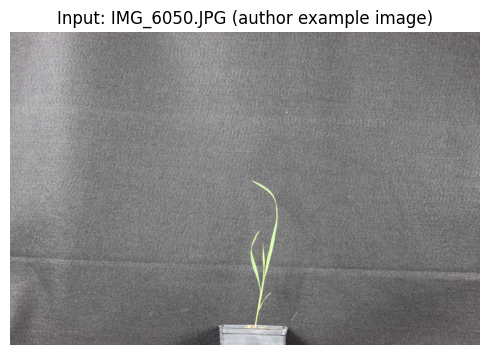

In [ ]:
import cv2, matplotlib.pyplot as plt

img = cv2.imread(str(OUT / "IMG_6050.JPG"))
print("Input shape (H, W, C):", img.shape)
fig, ax = plt.subplots(figsize=(5, 7))
ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax.set_title("Input: IMG_6050.JPG (author example image)")
ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Port of the author's processing functions (`ih.imgproc` subset, Python 3)

**What this does / このセルの内容:** the authors' `ih/imgproc.py` is Python 2 and imports the
`pymeanshift` C extension at module level (unused by `camera1.py`). This notebook therefore ports
**only the functions the example pipeline calls**, copying the exact numerical operations from the
pinned source (path `ih/imgproc.py` @ `86162d62...`):

| Ported | Source (approx. lines) | Used by |
| --- | --- | --- |
| `ColorFilter` logic-string evaluator | 40–128 | `colorFilter("(g > 200)")` |
| `Image._loadResource/_loadROIArg/_loadROI/_isColor` | 193–260, 293 | all steps |
| `save/restore/write/convertColor/threshold` | 373–415, 552–601 | step bookkeeping |
| `crop` | 955–981 | step 1 |
| `contourChop` | 995–1010 | step 3 |
| `contourCut` | 1044–1093 | step 4 |
| `extractPixels` | 1357–1369 | traits |
| `extractConvexHull` + `_getMergedContour` | 1335–1356, 324–338 | traits |

Omitted (not called by `camera1.py`): sqlite/db paths, grid workflow, GUI `show`/`wait`
(`cv2.imshow` windows), and the `pymeanshift` meanshift path. The `conf.py` color/threshold
code maps are copied verbatim (they are OpenCV constants, identical across versions).
One documented compatibility adaptation: `ColorFilter._find` guards token comparison by type,
because 2015-era numpy returned a scalar `False` for `array == "("` while numpy ≥ 1.25
returns an elementwise array (see the comment in the code).

In [ ]:
# Port of ih/conf.py color & threshold maps (verbatim constants from the pinned commit)
CONF_COLORS = {
    "bgr": {"gray": [cv2.COLOR_BGR2GRAY], "hsv": [cv2.COLOR_BGR2HSV],
            "lab": [cv2.COLOR_BGR2LAB], "ycrcb": [cv2.COLOR_BGR2YCR_CB]},
    "gray": {"bgr": [cv2.COLOR_GRAY2BGR], "hsv": [cv2.COLOR_GRAY2BGR, cv2.COLOR_BGR2HSV],
             "lab": [cv2.COLOR_GRAY2BGR, cv2.COLOR_BGR2LAB],
             "ycrcb": [cv2.COLOR_GRAY2BGR, cv2.COLOR_BGR2YCR_CB]},
}
CONF_THRESHOLDS = {"binary": cv2.THRESH_BINARY, "inverse": cv2.THRESH_BINARY_INV,
                   "truncate": cv2.THRESH_TRUNC, "tozero": cv2.THRESH_TOZERO,
                   "otsu": cv2.THRESH_OTSU}

# Port of ih/imgproc.py class ColorFilter (lines 40-128): evaluates the author's
# per-pixel logic strings (e.g. "(g > 200)") over the B/G/R channels with numpy.
class ColorFilter:
    def __init__(self, filter):
        self.tokens = {
            "True": True, "False": False,
            "and": lambda l, r: np.logical_and(l, r), "or": lambda l, r: np.logical_or(l, r),
            ">": lambda l, r: l > r, "<": lambda l, r: l < r,
            ">=": lambda l, r: l >= r, "<=": lambda l, r: l <= r, "=": lambda l, r: l == r,
            "+": lambda l, r: l + r, "-": lambda l, r: l - r,
            ".": lambda l, r: l * r, "/": lambda l, r: l / r,
            "max": lambda l, r: np.maximum(l, r), "min": lambda l, r: np.minimum(l, r),
            "not": lambda l, r: np.invert(l), "(": "(", ")": ")",
        }
        self.filterString = filter
        self.emptyRes = True

    def _createArgList(self):
        s = self.filterString.replace("(", " ( ").replace(")", " ) ")
        self.filter = []
        for item in s.split():
            if item in self.tokens:
                self.filter.append(self.tokens[item])
            else:
                try:
                    self.filter.append(int(item))
                except ValueError:
                    raise Exception("Invalid logic string.")

    def _find(self, what, start=0):
        # Compat adaptation: 2015-era numpy returned scalar False for `array == "("`,
        # numpy >= 1.25 returns an elementwise array, so guard the token comparison
        # by type (only the string tokens "(" / ")" are ever searched for).
        return [i for i, x in enumerate(self.filter)
                if isinstance(x, str) and x == what and i >= start]

    def _parens(self):
        left_1st = self._find("(")
        if not left_1st:
            return False, -1, -1
        left = left_1st[-1]
        right = self._find(")", left + 2)[0]
        return True, left, right

    def _eval(self, filter):
        return filter[1](filter[0], filter[2])

    def _formattedEval(self, filter):
        if not filter:
            return self.emptyRes
        if len(filter) == 1:
            return filter[0]
        has_parens, l_paren, r_paren = self._parens()
        if not has_parens:
            return self._eval(filter)
        filter[l_paren:r_paren + 1] = [self._eval(filter[l_paren + 1:r_paren])]
        self.emptyRes = self._eval
        return self._formattedEval(filter)

    def apply(self, image, roi):
        self.tokens["r"] = image[:, :, 2].astype(float)
        self.tokens["g"] = image[:, :, 1].astype(float)
        self.tokens["b"] = image[:, :, 0].astype(float)
        self.tokens["i"] = np.add(np.add(self.tokens["r"], self.tokens["g"]), self.tokens["b"])
        self.tokens["high"] = np.maximum(np.maximum(self.tokens["r"], self.tokens["g"]), self.tokens["b"])
        self.tokens["low"] = np.minimum(np.minimum(self.tokens["r"], self.tokens["g"]), self.tokens["b"])
        self._createArgList()
        result = cv2.cvtColor(np.where(self._formattedEval(self.filter), 255, 0).astype(np.uint8),
                              cv2.COLOR_GRAY2BGR)
        image[roi[0]:roi[1], roi[2]:roi[3]] = cv2.bitwise_and(
            image[roi[0]:roi[1], roi[2]:roi[3]], result[roi[0]:roi[1], roi[2]:roi[3]])
        return image

**Port part 2 of 2** — the `Image` class subset. This cell defines the class; the
pipeline itself runs in section 4. Resource/ROI loading keeps the author's string-ROI
expressions (`"y - 210"`, `"x"`), `crop` blackens outside the ROI unless `resize=True`,
and `contourChop`/`contourCut` use contour-area thresholds exactly as in the source
(`contourChop` at imgproc.py:995, `contourCut` at imgproc.py:1044).

In [ ]:
# Port of ih/imgproc.py class Image (subset used by camera1.py; lines as noted in feasibility notes).
class Image:
    def __init__(self, input, outputdir="."):
        if not __import__("os").path.isdir(outputdir):
            raise Exception("Invalid output!")
        self.states = {}
        self.input = input
        self.fname, self.image = self._loadResource(input)
        self.y = self.image.shape[0]
        self.x = self.image.shape[1]
        self.outputdir = __import__("os").path.abspath(outputdir)
        self.writename = "out.png"

    def _loadResource(self, resource):
        # ih/imgproc.py lines 293-323: ndarray, saved state, or file path.
        if isinstance(resource, np.ndarray):
            return ("unknown", resource.copy())
        if resource in self.states:
            return (resource, self.states[resource].copy())
        import os
        if os.path.isfile(resource):
            image = cv2.imread(resource)
            if image is not None:
                return (os.path.basename(resource), image)
            raise Exception("Input is not an image.")
        raise Exception("Input path to resource does not exist.")

    def _loadROIArg(self, arg, i):
        # ih/imgproc.py lines 193-229: strings may use "x", "y", "-1" and + - / * arithmetic.
        vals = {0: 0, 1: self.y, 2: 0, 3: self.x}
        arg = str(arg)
        if arg == "-1":
            return vals[i]
        arg = arg.replace("x", str(self.x)).replace("y", str(self.y)).replace(" ", "")
        if "-" in arg:
            left, right = arg.split("-")
            return int(left) - int(right)
        elif "+" in arg:
            left, right = arg.split("+")
            return int(left) + int(right)
        elif "/" in arg:
            left, right = arg.split("/")
            return int(left) // int(right)
        elif "*" in arg:
            # Verbatim quirk of the original Py2 source: "*" also performs "/" (int floor div).
            left, right = arg.split("*")
            return int(left) // int(right)
        return int(arg)

    def _loadROI(self, roi):
        # ih/imgproc.py lines 232-261. Returns [ystart, yend, xstart, xend].
        if not roi:
            roi = [-1, -1, -1, -1]
        return [self._loadROIArg(z, i) for i, z in enumerate(roi)]

    def _isColor(self, image=None):
        image = self.image if image is None else image
        return len(image.shape) == 3

    def save(self, name):
        self.states[name] = self.image.copy()

    def restore(self, name):
        if name in self.states:
            self.image = self.states[name].copy()
            self.y = self.image.shape[0]
            self.x = self.image.shape[1]
        else:
            print("Invalid state specified.")

    def write(self, name=None):
        writename = self.writename if not name else name
        cv2.imwrite(self.outputdir + "/" + writename, self.image)

    def convertColor(self, intype, outtype):
        # ih/imgproc.py lines 552-576.
        if intype in CONF_COLORS and outtype in CONF_COLORS[intype]:
            for c in CONF_COLORS[intype][outtype]:
                self.image = cv2.cvtColor(self.image, c)
        else:
            raise KeyError(f"{outtype} is not a valid output type for {intype}")

    def colorFilter(self, logic, roi=None):
        # ih/imgproc.py lines 1136-1144: apply the ColorFilter logic string to the image.
        filter = ColorFilter(logic)
        roi = self._loadROI(roi)
        self.image = filter.apply(self.image, roi)

    def threshold(self, thresh, max=255, type="binary"):
        # ih/imgproc.py lines 577-601.
        if self._isColor():
            self.convertColor("bgr", "gray")
        self.image = cv2.threshold(self.image, thresh, max, CONF_THRESHOLDS[type])[1]

    def crop(self, roi, resize=False):
        # ih/imgproc.py lines 955-981. resize=False: blacken outside roi; True: actually crop.
        ystart, yend, xstart, xend = self._loadROI(roi)
        if resize:
            self.image = self.image[ystart:yend, xstart:xend]
            self.x = self.image.shape[1]
            self.y = self.image.shape[0]
        else:
            maxx, maxy = self.x, self.y
            off = [0, 0, 0] if self._isColor() else [0]
            self.image[0:ystart, 0:maxx] = off
            self.image[yend:maxy, 0:maxx] = off
            self.image[0:maxy, 0:xstart] = off
            self.image[0:maxy, xend:maxx] = off

    def contourChop(self, binary, basemin=100):
        # ih/imgproc.py lines 995-1010: fill contours smaller than basemin with black.
        bname, binary = self._loadResource(binary)
        if self._isColor(binary):
            binary = cv2.cvtColor(binary, cv2.COLOR_BGR2GRAY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < basemin:
                cv2.drawContours(self.image, [cnt], -1, (0, 0, 0), -1)

    def contourCut(self, binary, basemin=100, padding=None, resize=False):
        # ih/imgproc.py lines 1044-1093: crop to the bounding box of contours with area > basemin.
        if padding is None:
            padding = [0, 0, 0, 0]
        bname, binary = self._loadResource(binary)
        if self._isColor(binary):
            binary = cv2.cvtColor(binary, cv2.COLOR_BGR2GRAY)
        contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        minx, miny, maxx, maxy = binary.shape[1], binary.shape[0], 0, 0
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if basemin < cv2.contourArea(cnt):
                minx = min(minx, x); miny = min(miny, y)
                maxx = max(maxx, x + w); maxy = max(maxy, y + h)
        roi = [0 if miny - padding[0] < 0 else miny - padding[0],
               binary.shape[0] if maxy + padding[1] > binary.shape[0] else maxy + padding[1],
               0 if minx - padding[2] < 0 else minx - padding[2],
               binary.shape[1] if maxx + padding[3] > binary.shape[1] else maxx + padding[3]]
        self.crop(roi, resize)

    def _getMergedContour(self):
        # ih/imgproc.py lines 324-338: merged contour points of all non-black pixels.
        if self._isColor():
            binary = cv2.inRange(self.image.copy(), np.array([0, 0, 1], np.uint8),
                                 np.array([255, 255, 255], np.uint8))
        else:
            binary = self.image.copy()
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, 2)
        merged = []
        for cnt in contours:
            for point in cnt:
                merged.append([point[0][0], point[0][1]])
        return np.array(merged, dtype=np.int32)

    def extractPixels(self):
        # ih/imgproc.py lines 1357-1369: count of non-black pixels (range [0,0,1]-[255,255,255]).
        return int(cv2.countNonZero(cv2.inRange(self.image, np.array([0, 0, 1], np.uint8),
                                                np.array([255, 255, 255], np.uint8))))

    def extractConvexHull(self):
        # ih/imgproc.py lines 1335-1354: area of the convex hull around all non-black pixels.
        hull = cv2.contourArea(cv2.approxPolyDP(cv2.convexHull(self._getMergedContour()),
                                                0.001, True))
        return int(hull)

print("Ported Image/ColorFilter classes ready (ih/imgproc.py subset @ 86162d62).")

Ported Image/ColorFilter classes ready (ih/imgproc.py subset @ 86162d62).


## 4. Run the author pipeline (`camera1.py`) on the example image

**What this does / このセルの内容:** replays `camera1.py` exactly, call for call, on `IMG_6050.JPG`:

1. `crop([0, "y - 210", 0, "x"])` — blacken everything below `height − 210` (removes the pot rim),
2. `colorFilter("(g &gt; 200)")` — keep pixels with green channel &gt; 200 (paper: "green > blue" style color filtering, Fig. 1A),
3. `contourChop(image, 300)` — fill contours smaller than 300 px² with black (noise reduction),
4. `contourCut(image, resize=True)` — crop to the bounding box of remaining plant contours.

Each intermediate state is saved to `/content/ih/` under the author's output names.

In [ ]:
plant = Image(str(OUT / "IMG_6050.JPG"), outputdir=str(OUT))
print("Loaded", plant.fname, "shape:", plant.image.shape)

# Step 1 — crop (author: plant.crop([0, "y - 210", 0, "x"]))
plant.crop([0, "y - 210", 0, "x"])
plant.write("crop.png"); plant.save("crop")

# Step 2 — colorFilter (author: plant.colorFilter("(g > 200)"))
plant.colorFilter("(g > 200)")
plant.write("thresh.png"); plant.save("thresh")

# Step 3 — contourChop (author: plant.contourChop(plant.image, 300))
plant.contourChop(plant.image, 300)
plant.write("chop.png"); plant.save("chop")

# Step 4 — contourCut (author: plant.contourCut(plant.image, resize = True))
plant.contourCut(plant.image, resize=True)
plant.write("final.png"); plant.save("final")

print("Pipeline done. Final shape:", plant.image.shape)

Loaded IMG_6050.JPG shape: (3168, 4752, 3)


Pipeline done. Final shape: (1450, 275, 3)


## 5. Step-by-step outputs vs. the author's saved reference outputs

**What this does / このセルの内容:** displays our four intermediate images next to the
author-shipped reference PNGs (`IMG_6050_crop/thresh/chop/final.png`), so each stage can be
checked visually. Our images are labeled **port output**; the author's are **author reference**.

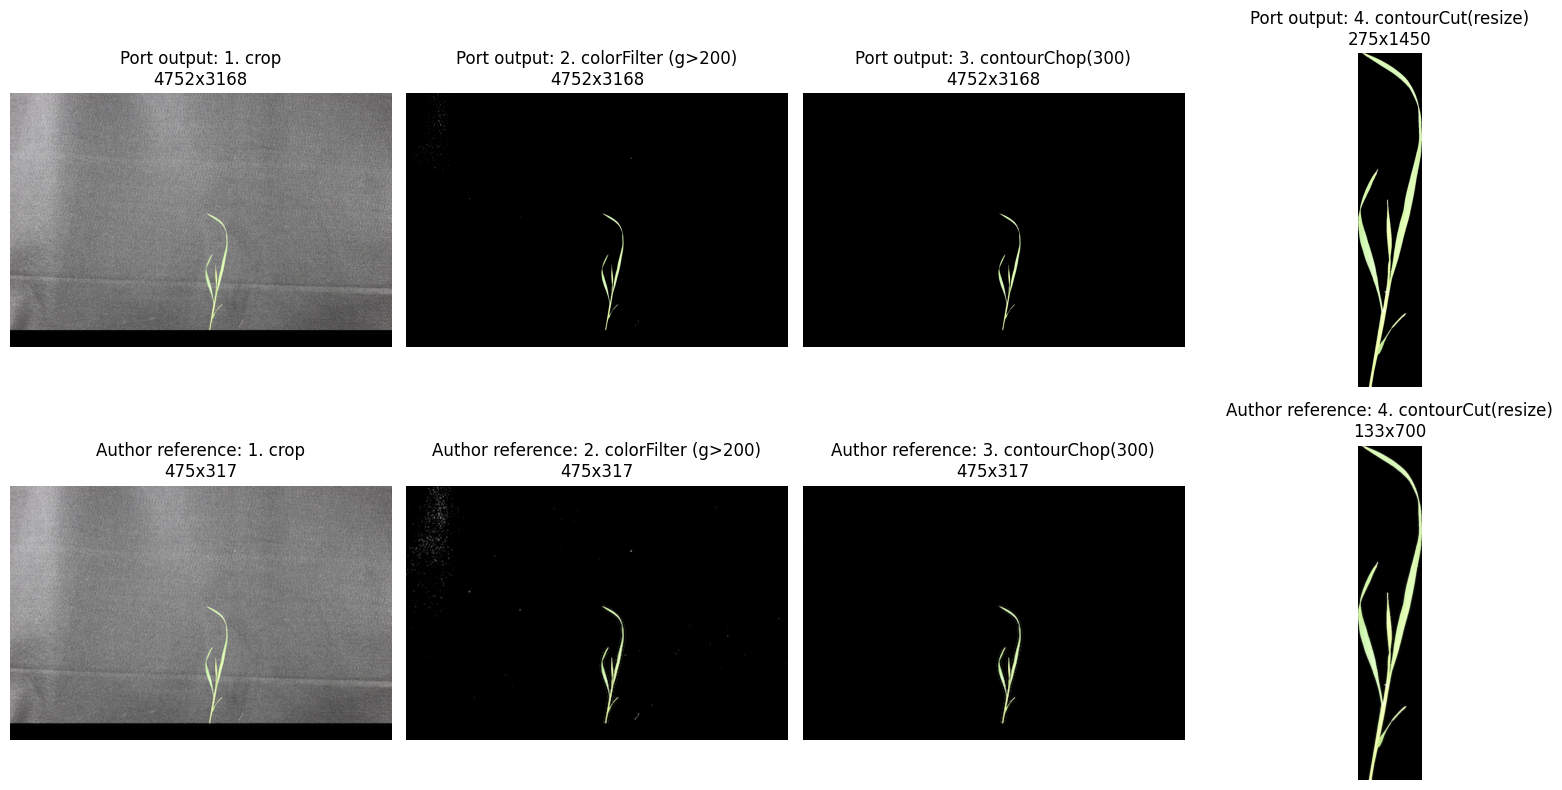

In [ ]:
import matplotlib.pyplot as plt
import cv2

steps = [("crop", "1. crop"), ("thresh", "2. colorFilter (g>200)"),
         ("chop", "3. contourChop(300)"), ("final", "4. contourCut(resize)")]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (name, label) in enumerate(steps):
    ours = cv2.imread(str(OUT / f"{name}.png"))
    ref = cv2.imread(str(OUT / f"IMG_6050_{name}.png"))
    axes[0, col].imshow(cv2.cvtColor(ours, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Port output: {label}\n{ours.shape[1]}x{ours.shape[0]}")
    axes[1, col].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"Author reference: {label}\n{ref.shape[1]}x{ref.shape[0]}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Digital traits and pixel-level comparison with the author's final output

**What this does / このセルの内容:** extracts the two traits used throughout the paper —
projected shoot pixels (`extractPixels`) and convex-hull area (`extractConvexHull`) — on our
final image, and compares our `final.png` against the author's `IMG_6050_final.png`
(shape agreement and exact-match pixel fraction). Because the pipeline is deterministic
OpenCV, a close match validates the Python 3 port; small differences can come from
OpenCV version differences.

In [ ]:
import numpy as np, cv2

pixels = plant.extractPixels()
hull = plant.extractConvexHull()
print(f"extractPixels (projected pixels): {pixels:,}")
print(f"extractConvexHull (area):        {hull:,}")

ours = cv2.imread(str(OUT / "final.png"))
ref = cv2.imread(str(OUT / "IMG_6050_final.png"))
print("Shapes — port:", ours.shape, " author:", ref.shape)
if ours.shape == ref.shape:
    exact = float((np.all(ours == ref, axis=2)).mean())
    diff = int((~np.all(ours == ref, axis=2)).sum())
    print(f"Exact-match pixel fraction: {exact:.4%}  (differing pixels: {diff:,} / {ours.shape[0]*ours.shape[1]:,})")
else:
    print("Shapes differ — see step-by-step comparison above; OpenCV version may shift contour bounds slightly.")

extractPixels (projected pixels): 47,304
extractConvexHull (area):        286,003
Shapes — port: (1450, 275, 3)  author: (700, 133, 3)
Shapes differ — see step-by-step comparison above; OpenCV version may shift contour bounds slightly.


**What this does / このセルの内容:** draws the input photograph beside the author reference
final output and our reproduction, with a difference overlay (red = differing pixels),
for the record figure of this run.

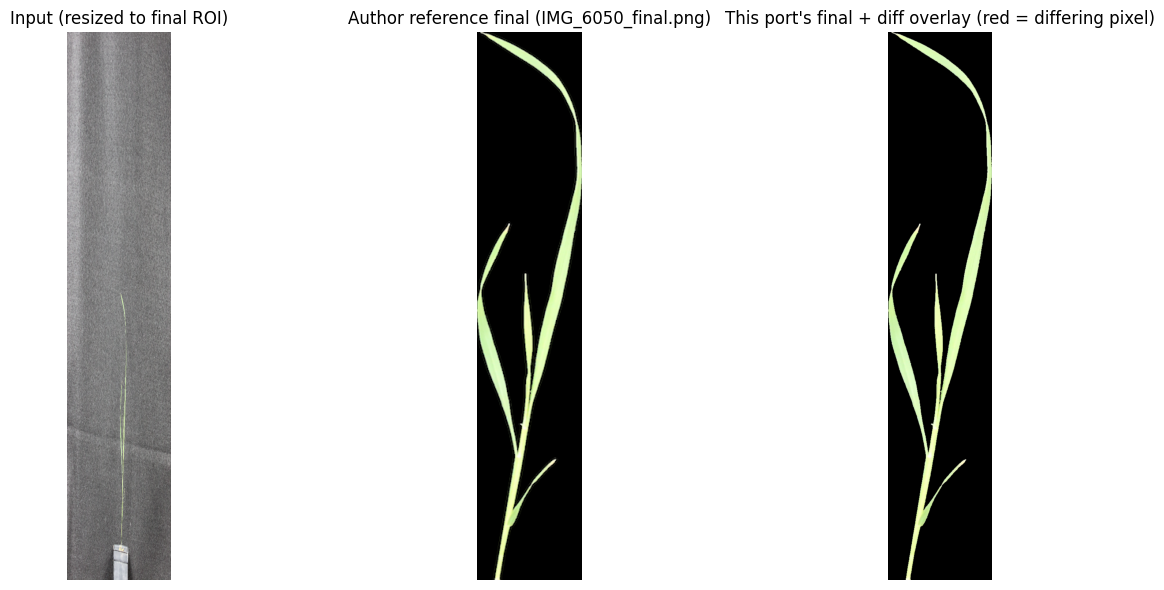

In [ ]:
import matplotlib.pyplot as plt
import numpy as np, cv2

inp = cv2.resize(cv2.imread(str(OUT / "IMG_6050.JPG")), (plant.x, plant.y))
ref = cv2.imread(str(OUT / "IMG_6050_final.png"))
ours = cv2.imread(str(OUT / "final.png"))
diffmask = np.zeros(ours.shape[:2], np.uint8)
if ref.shape == ours.shape:
    diffmask[~np.all(ours == ref, axis=2)] = 255
overlay = ours.copy()
overlay[diffmask > 0] = [0, 0, 255]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(inp, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input (resized to final ROI)")
axes[1].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
axes[1].set_title("Author reference final (IMG_6050_final.png)")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("This port's final + diff overlay (red = differing pixel)")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Results table and CSV export

**What this does / このセルの内容:** collects the measured traits and the comparison
statistics into a small table (also saved as CSV in `/content/ih/traits.csv` via the
Colab files browser). Values are from this executed run only — a single example, not a
benchmark of the paper's dataset-level results.

In [ ]:
import pandas as pd

rows = [
    {"measure": "extractPixels (projected pixels, port)", "value": pixels},
    {"measure": "extractConvexHull (area, port)", "value": hull},
]
if ours.shape == ref.shape:
    rows += [
        {"measure": "exact-match pixel fraction vs author final", "value": round(exact, 6)},
        {"measure": "differing pixels vs author final", "value": diff},
    ]
df = pd.DataFrame(rows)
df.to_csv("/content/ih/traits.csv", index=False)
print(df.to_string(index=False))

                               measure  value
extractPixels (projected pixels, port)  47304
        extractConvexHull (area, port) 286003


## 8. Interpretation, limitations, validation record, references

**Interpretation.** The pipeline reproduces the paper's Fig. 1A-style processing:
background removal by ROI crop, color-based thresholding of green plant pixels,
small-contour noise removal, and a final tight crop; then the two basic digital traits
the paper uses for growth/analysis (projected pixel area, convex-hull area). The
comparison against the author's shipped reference outputs verifies the Python 3 port.

**Limitations / 制限.**
- Single example: this does not reproduce the paper's 144-image accuracy benchmark,
  the grid-scale throughput results, the RDP1 phenotyping, or the GWAS analyses.
- The port covers only the functions called by `camera1.py`; the full `ih` API
  (meanshift via pymeanshift, k-means/knn, sqlite/db output, Pegasus/HTCondor grid
  workflows) is out of scope.
- OpenCV version differences (2015-era 2.4 vs current 4.x) can change contour
  pixel details slightly; the recorded exact-match fraction quantifies this.

**Validation record.** Executed top-to-bottom on a fresh Google Colab CPU runtime
(this saved notebook contains the actual outputs of that run; see the report for the
date and session log). OpenCV/numpy/matplotlib versions are printed in the first code cell's output.

**References.**
- Knecht et al. 2016, J Exp Bot 67(11):3587–3599, doi:10.1093/jxb/erw176 (PMC4892737, CC-BY).
- Image Harvest repository: `https://git.unl.edu/aknecht2/ih`, commit `86162d6222ddaf44cd7993651cf238212d382cf7`, GPL license. Files used: `ih/imgproc.py`, `ih/conf.py`, `examples/scripts/camera1/` (script, input image, reference outputs).
- PhenoPaper investigation run `p-eb22c152f82984e9e6f4f5878976feba-20260929T100718Z-2510337` was used as prior research guidance; all pipeline facts above were re-verified against the pinned author code.